In [1]:
# Настройка эксперимента

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

SEED = 42
BASE_K = 6
RANDOM_STATES = list(range(10))
SILHOUETTE_K = range(2, 9)

FEATURES = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)",
]

DERIVED_FEATURE = "Spending_to_Income"

DATA_URL = (
    "https://raw.githubusercontent.com/tanishq21/Mall-Customers/"
    "main/Mall_Customers.csv"
)

OUTLIER_THRESHOLDS = [3.0, 2.5]

np.random.seed(SEED)

print("Параметры эксперимента:")
print(f"BASE_K = {BASE_K}")
print(f"random_state = {RANDOM_STATES}")
print(f"Признаки = {FEATURES}")


Параметры эксперимента:
BASE_K = 6
random_state = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Признаки = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [2]:
# Загрузка и первичная проверка данных

try:
    df = pd.read_csv(DATA_URL)
except Exception:
    # Если загрузка по URL недоступна, загрузите Mall_Customers.csv в Colab
    # и повторно выполните эту ячейку.
    from google.colab import files
    uploaded = files.upload()
    local_name = next(iter(uploaded))
    df = pd.read_csv(local_name)

df.columns = [col.strip() for col in df.columns]

print(f"Размер данных: {df.shape}")
display(df.head())

print("\nПропуски:")
display(df.isna().sum().to_frame("Количество пропусков"))

print("\nОписательная статистика:")
display(df[FEATURES].describe().round(2))


Размер данных: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Пропуски:


,Количество пропусков
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



Описательная статистика:


,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


In [3]:
# Подготовка признаков и стандартизация

X = df[FEATURES].copy()

# K-Means использует расстояния, поэтому признаки приводим к сопоставимому масштабу.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Средние значения после StandardScaler:")
print(np.round(X_scaled.mean(axis=0), 4))

print("\nСтандартные отклонения после StandardScaler:")
print(np.round(X_scaled.std(axis=0), 4))


Средние значения после StandardScaler:
[-0. -0. -0.]

Стандартные отклонения после StandardScaler:
[1. 1. 1.]


In [4]:
# 1. Базовая сегментация клиентов по трём признакам

baseline_model = KMeans(
    n_clusters=BASE_K,
    init="k-means++",
    n_init=20,
    random_state=SEED,
)

baseline_labels = baseline_model.fit_predict(X_scaled)

df_baseline = df.copy()
df_baseline["Cluster"] = baseline_labels

baseline_silhouette = silhouette_score(X_scaled, baseline_labels)

print(f"Количество кластеров: {BASE_K}")
print(f"Silhouette Score: {baseline_silhouette:.4f}")

print("\nРазмеры кластеров:")
display(df_baseline["Cluster"].value_counts().sort_index().to_frame("Количество клиентов"))

print("\nПрофиль кластеров:")
baseline_profile = (
    df_baseline.groupby("Cluster")[FEATURES]
    .mean()
    .round(2)
)
display(baseline_profile)


Количество кластеров: 6
Silhouette Score: 0.4274

Размеры кластеров:


,Количество клиентов
Cluster,
0,33
1,45
2,24
3,39
4,38
5,21



Профиль кластеров:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,41.94,88.94,16.97
1,56.33,54.27,49.07
2,25.25,25.83,76.92
3,32.69,86.54,82.13
4,26.68,57.58,47.79
5,45.52,26.29,19.38


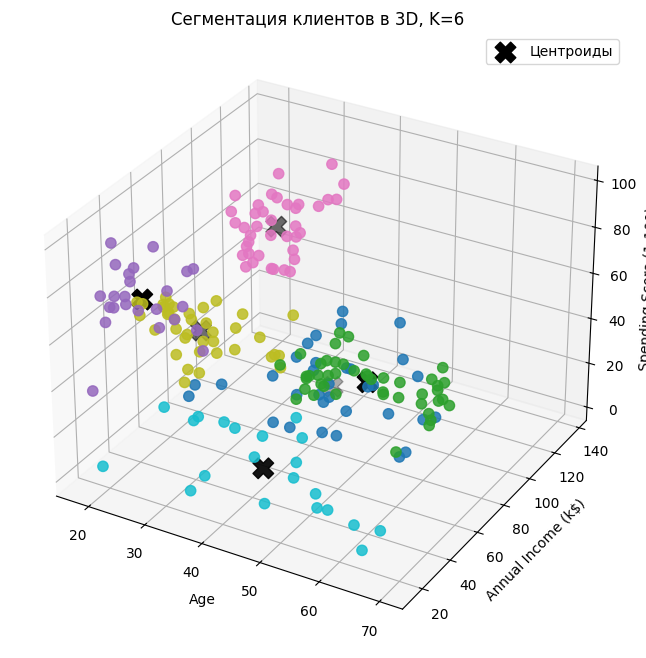

In [5]:
# 1. Визуализация сегментов в 3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    df_baseline["Age"],
    df_baseline["Annual Income (k$)"],
    df_baseline["Spending Score (1-100)"],
    c=df_baseline["Cluster"],
    cmap="tab10",
    s=55,
    alpha=0.85,
)

centers_original = scaler.inverse_transform(baseline_model.cluster_centers_)

ax.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    centers_original[:, 2],
    c="black",
    marker="X",
    s=220,
    label="Центроиды",
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.set_title(f"Сегментация клиентов в 3D, K={BASE_K}")
ax.legend()
plt.show()


In [6]:
# 2. Сравнение K-Means++ и стандартного K-Means

# n_init=1 используется намеренно:
# так мы сравниваем влияние самой инициализации и random_state,
# а не скрываем его множественными внутренними запусками.

stability_rows = []
stability_labels = {}

for init_method in ["k-means++", "random"]:
    for random_state in RANDOM_STATES:
        model = KMeans(
            n_clusters=BASE_K,
            init=init_method,
            n_init=1,
            random_state=random_state,
        )
        labels = model.fit_predict(X_scaled)

        stability_labels[(init_method, random_state)] = labels

        stability_rows.append({
            "Инициализация": init_method,
            "random_state": random_state,
            "Inertia": model.inertia_,
            "Silhouette": silhouette_score(X_scaled, labels),
        })

stability_df = pd.DataFrame(stability_rows)

print("Результаты отдельных запусков:")
display(stability_df.round(4))

print("\nСредние значения и разброс:")
stability_summary = (
    stability_df.groupby("Инициализация")
    .agg(
        Silhouette_mean=("Silhouette", "mean"),
        Silhouette_std=("Silhouette", "std"),
        Inertia_mean=("Inertia", "mean"),
        Inertia_std=("Inertia", "std"),
    )
    .round(4)
)
display(stability_summary)

pairwise_ari_rows = []

for init_method in ["k-means++", "random"]:
    labels_list = [
        stability_labels[(init_method, random_state)]
        for random_state in RANDOM_STATES
    ]

    ari_values = [
        adjusted_rand_score(labels_list[i], labels_list[j])
        for i in range(len(labels_list))
        for j in range(i + 1, len(labels_list))
    ]

    pairwise_ari_rows.append({
        "Инициализация": init_method,
        "Средний ARI": np.mean(ari_values),
        "Std ARI": np.std(ari_values),
        "Минимальный ARI": np.min(ari_values),
        "Максимальный ARI": np.max(ari_values),
    })

ari_df = pd.DataFrame(pairwise_ari_rows).round(4)

print("Стабильность разбиений по Adjusted Rand Index:")
display(ari_df)


Результаты отдельных запусков:


,Инициализация,random_state,Inertia,Silhouette
0,k-means++,0,149.3917,0.3926
1,k-means++,1,157.4223,0.3705
2,k-means++,2,133.8684,0.4284
3,k-means++,3,133.8683,0.4274
4,k-means++,4,157.4223,0.3705
5,k-means++,5,152.3186,0.3965
6,k-means++,6,134.3528,0.4311
7,k-means++,7,133.8889,0.4269
8,k-means++,8,149.4761,0.3880
9,k-means++,9,157.5781,0.3949



Средние значения и разброс:


,Silhouette_mean,Silhouette_std,Inertia_mean,Inertia_std
Инициализация,,,,
k-means++,0.4027,0.0239,145.9587,10.7247
random,0.3940,0.0253,149.3379,11.1133


Стабильность разбиений по Adjusted Rand Index:


,Инициализация,Средний ARI,Std ARI,Минимальный ARI,Максимальный ARI
0,k-means++,0.7872,0.1102,0.6256,1.0
1,random,0.7071,0.1260,0.4520,1.0


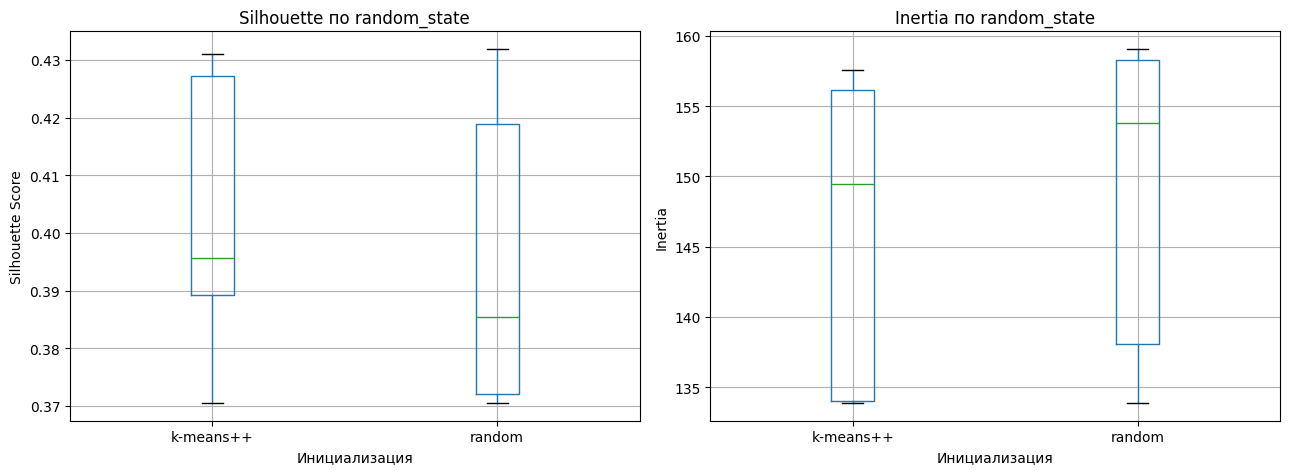

In [7]:
# 2. Визуализация стабильности запусков

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

stability_df.boxplot(
    column="Silhouette",
    by="Инициализация",
    ax=axes[0],
)
axes[0].set_title("Silhouette по random_state")
axes[0].set_xlabel("Инициализация")
axes[0].set_ylabel("Silhouette Score")
axes[0].get_figure().suptitle("")

stability_df.boxplot(
    column="Inertia",
    by="Инициализация",
    ax=axes[1],
)
axes[1].set_title("Inertia по random_state")
axes[1].set_xlabel("Инициализация")
axes[1].set_ylabel("Inertia")
axes[1].get_figure().suptitle("")

plt.tight_layout()
plt.show()


In [8]:
# 3. Поиск выбросов по Z-оценке

# Функция соответствует подходу урока:
# выбросом считаем объект, у которого абсолютная Z-оценка
# хотя бы по одному признаку превышает заданный порог.

def find_outliers_zscore(dataframe, features, threshold):
    values = dataframe[features].astype(float)
    z_scores = (values - values.mean()) / values.std(ddof=0)
    mask = (np.abs(z_scores) > threshold).any(axis=1)
    return mask, z_scores

outlier_results = []

for threshold in OUTLIER_THRESHOLDS:
    mask, _ = find_outliers_zscore(df, FEATURES, threshold)
    outlier_results.append({
        "Порог |Z|": threshold,
        "Количество выбросов": int(mask.sum()),
        "Доля данных, %": round(mask.mean() * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_results)
display(outlier_summary)

mask_3, z_3 = find_outliers_zscore(df, FEATURES, 3.0)
mask_25, z_25 = find_outliers_zscore(df, FEATURES, 2.5)

print("При строгом пороге |Z| > 3:")
display(df.loc[mask_3, ["CustomerID"] + FEATURES])

print("\nДля учебного сравнения используем |Z| > 2.5:")
outliers = df.loc[mask_25, ["CustomerID"] + FEATURES].copy()
display(outliers)

df_clean = df.loc[~mask_25].copy()
print(f"До удаления: {len(df)} строк")
print(f"После удаления: {len(df_clean)} строк")


,Порог |Z|,Количество выбросов,"Доля данных, %"
0,3.0,0,0.0
1,2.5,2,1.0


При строгом пороге |Z| > 3:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)



Для учебного сравнения используем |Z| > 2.5:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
198,199,32,137,18
199,200,30,137,83


До удаления: 200 строк
После удаления: 198 строк


In [9]:
# 3. Кластеризация до и после удаления выбросов

X_before = df[FEATURES]
X_before_scaled = StandardScaler().fit_transform(X_before)

scaler_after = StandardScaler()
X_after_scaled = scaler_after.fit_transform(df_clean[FEATURES])

model_before = KMeans(
    n_clusters=BASE_K,
    init="k-means++",
    n_init=20,
    random_state=SEED,
)
labels_before = model_before.fit_predict(X_before_scaled)

model_after = KMeans(
    n_clusters=BASE_K,
    init="k-means++",
    n_init=20,
    random_state=SEED,
)
labels_after = model_after.fit_predict(X_after_scaled)

outlier_compare = pd.DataFrame({
    "Показатель": [
        "Количество объектов",
        "Silhouette Score",
        "Inertia",
        "Inertia на объект",
    ],
    "До удаления": [
        len(df),
        silhouette_score(X_before_scaled, labels_before),
        model_before.inertia_,
        model_before.inertia_ / len(df),
    ],
    "После удаления": [
        len(df_clean),
        silhouette_score(X_after_scaled, labels_after),
        model_after.inertia_,
        model_after.inertia_ / len(df_clean),
    ],
})

display(outlier_compare.round(4))

df_before = df.copy()
df_before["Cluster"] = labels_before

df_after = df_clean.copy()
df_after["Cluster"] = labels_after

print("Выбросы и их исходные кластеры:")
outlier_with_clusters = df.loc[mask_25, ["CustomerID"] + FEATURES].copy()
outlier_with_clusters["Исходный кластер"] = labels_before[mask_25]
display(outlier_with_clusters)


,Показатель,До удаления,После удаления
0,Количество объектов,200.0000,198.0000
1,Silhouette Score,0.4274,0.4338
2,Inertia,133.8683,128.6389
3,Inertia на объект,0.6693,0.6497


Выбросы и их исходные кластеры:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Исходный кластер
198,199,32,137,18,0
199,200,30,137,83,3


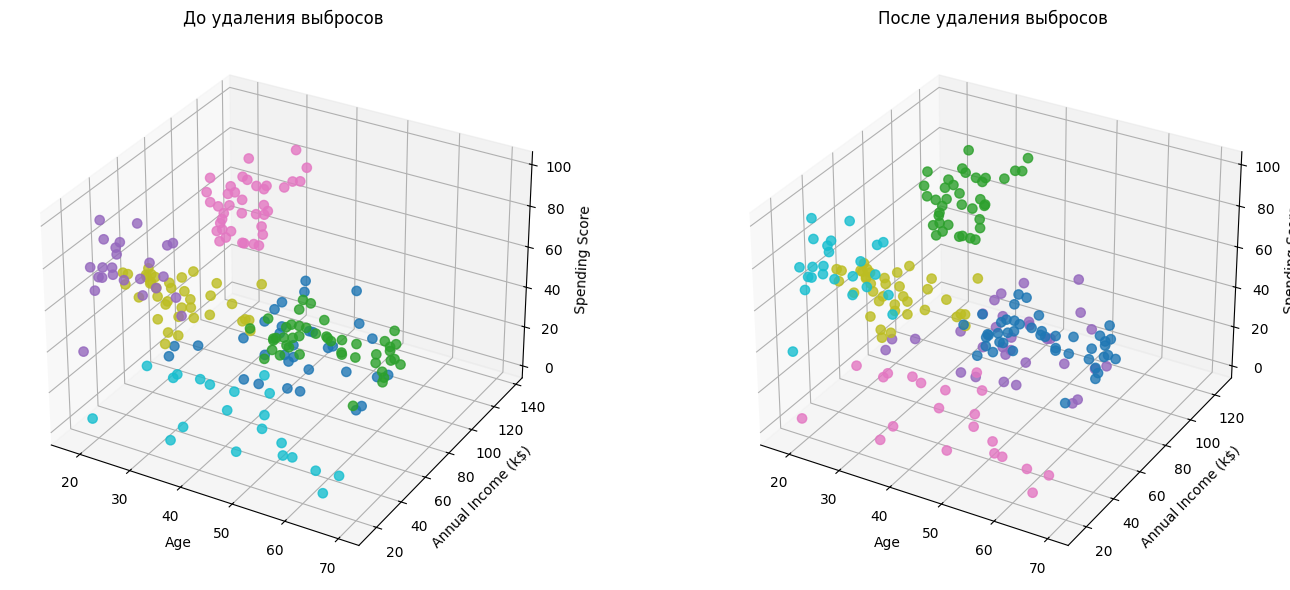

In [10]:
# 3. 3D-сравнение до и после удаления выбросов

fig = plt.figure(figsize=(15, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(
    df_before["Age"],
    df_before["Annual Income (k$)"],
    df_before["Spending Score (1-100)"],
    c=df_before["Cluster"],
    cmap="tab10",
    s=45,
    alpha=0.8,
)
ax1.set_title("До удаления выбросов")
ax1.set_xlabel("Age")
ax1.set_ylabel("Annual Income (k$)")
ax1.set_zlabel("Spending Score")

ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    df_after["Age"],
    df_after["Annual Income (k$)"],
    df_after["Spending Score (1-100)"],
    c=df_after["Cluster"],
    cmap="tab10",
    s=45,
    alpha=0.8,
)
ax2.set_title("После удаления выбросов")
ax2.set_xlabel("Age")
ax2.set_ylabel("Annual Income (k$)")
ax2.set_zlabel("Spending Score")

plt.tight_layout()
plt.show()


In [11]:
# 4. Подбор количества кластеров методом силуэта

silhouette_rows = []

for k in SILHOUETTE_K:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=SEED,
    )
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    silhouette_rows.append({
        "k": k,
        "Silhouette Score": score,
        "Inertia": model.inertia_,
    })

silhouette_df = pd.DataFrame(silhouette_rows)

display(silhouette_df.round(4))

best_k = int(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(),
        "k",
    ]
)
best_silhouette = float(
    silhouette_df.loc[
        silhouette_df["Silhouette Score"].idxmax(),
        "Silhouette Score",
    ]
)

print(f"Лучшее k по Silhouette Score: {best_k}")
print(f"Максимальный Silhouette Score: {best_silhouette:.4f}")


,k,Silhouette Score,Inertia
0,2,0.3355,389.3862
1,3,0.3578,295.2122
2,4,0.4040,205.2251
3,5,0.4166,168.2476
4,6,0.4274,133.8683
5,7,0.4172,117.0116
6,8,0.4087,103.8286


Лучшее k по Silhouette Score: 6
Максимальный Silhouette Score: 0.4274


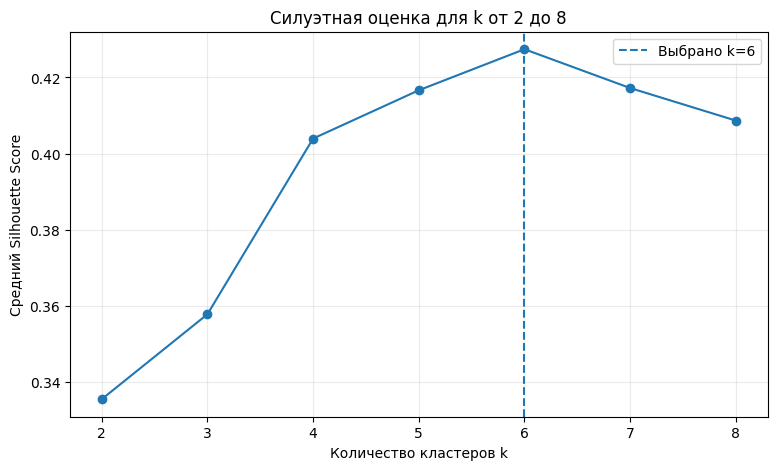

In [12]:
# 4. Визуализация силуэтных коэффициентов

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    silhouette_df["k"],
    silhouette_df["Silhouette Score"],
    marker="o",
)
ax.axvline(
    best_k,
    linestyle="--",
    label=f"Выбрано k={best_k}",
)

ax.set_xlabel("Количество кластеров k")
ax.set_ylabel("Средний Silhouette Score")
ax.set_title("Силуэтная оценка для k от 2 до 8")
ax.set_xticks(list(SILHOUETTE_K))
ax.grid(alpha=0.25)
ax.legend()

plt.show()


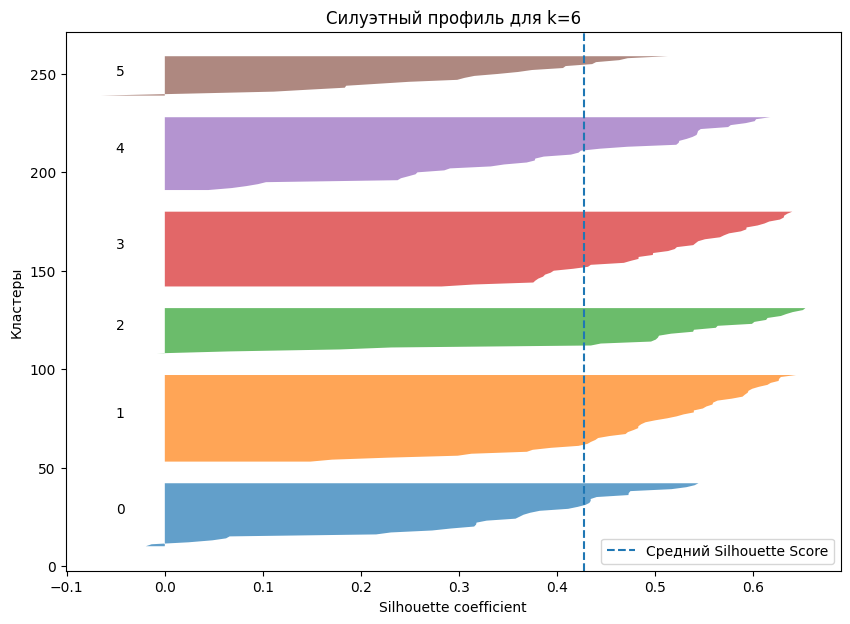

In [13]:
# 4. Детальный силуэтный график для выбранного k

best_model = KMeans(
    n_clusters=best_k,
    init="k-means++",
    n_init=20,
    random_state=SEED,
)
best_labels = best_model.fit_predict(X_scaled)

sample_silhouette_values = silhouette_samples(X_scaled, best_labels)

fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10

for cluster_id in range(best_k):
    cluster_values = sample_silhouette_values[best_labels == cluster_id]
    cluster_values.sort()

    size_cluster = len(cluster_values)
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        alpha=0.7,
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(cluster_id),
    )

    y_lower = y_upper + 10

ax.axvline(
    silhouette_score(X_scaled, best_labels),
    linestyle="--",
    label="Средний Silhouette Score",
)

ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Кластеры")
ax.set_title(f"Силуэтный профиль для k={best_k}")
ax.legend()

plt.show()


In [14]:
# 5. Создание нового признака и сравнение с базовой моделью

df_engineered = df.copy()

# Это не фактическая доля денежных расходов:
# Spending Score — оценочный балл, а не сумма расходов.
# Признак используется именно как производное соотношение
# "оценка расходов / годовой доход".
df_engineered[DERIVED_FEATURE] = (
    df_engineered["Spending Score (1-100)"]
    / df_engineered["Annual Income (k$)"]
)

FEATURES_ENGINEERED = FEATURES + [DERIVED_FEATURE]

scaler_engineered = StandardScaler()
X_engineered_scaled = scaler_engineered.fit_transform(
    df_engineered[FEATURES_ENGINEERED]
)

engineered_silhouette_rows = []

for k in SILHOUETTE_K:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=SEED,
    )
    labels = model.fit_predict(X_engineered_scaled)

    engineered_silhouette_rows.append({
        "k": k,
        "Silhouette Score": silhouette_score(
            X_engineered_scaled,
            labels,
        ),
    })

engineered_silhouette_df = pd.DataFrame(engineered_silhouette_rows)

display(
    engineered_silhouette_df.round(4)
)

engineered_best_k = int(
    engineered_silhouette_df.loc[
        engineered_silhouette_df["Silhouette Score"].idxmax(),
        "k",
    ]
)

engineered_model = KMeans(
    n_clusters=engineered_best_k,
    init="k-means++",
    n_init=20,
    random_state=SEED,
)
engineered_labels = engineered_model.fit_predict(X_engineered_scaled)

engineered_score = silhouette_score(
    X_engineered_scaled,
    engineered_labels,
)

print(f"Лучшее k после добавления нового признака: {engineered_best_k}")
print(f"Silhouette Score: {engineered_score:.4f}")

comparison_features = pd.DataFrame({
    "Модель": [
        "Базовая: 3 признака",
        "С новым признаком: 4 признака",
    ],
    "Количество признаков": [3, 4],
    "Лучшее k": [best_k, engineered_best_k],
    "Silhouette Score": [best_silhouette, engineered_score],
})

display(comparison_features.round(4))


,k,Silhouette Score
0,2,0.3131
1,3,0.3443
2,4,0.3892
3,5,0.4105
4,6,0.4246
5,7,0.4234
6,8,0.4075


Лучшее k после добавления нового признака: 6
Silhouette Score: 0.4246


,Модель,Количество признаков,Лучшее k,Silhouette Score
0,Базовая: 3 признака,3,6,0.4274
1,С новым признаком: 4 признака,4,6,0.4246


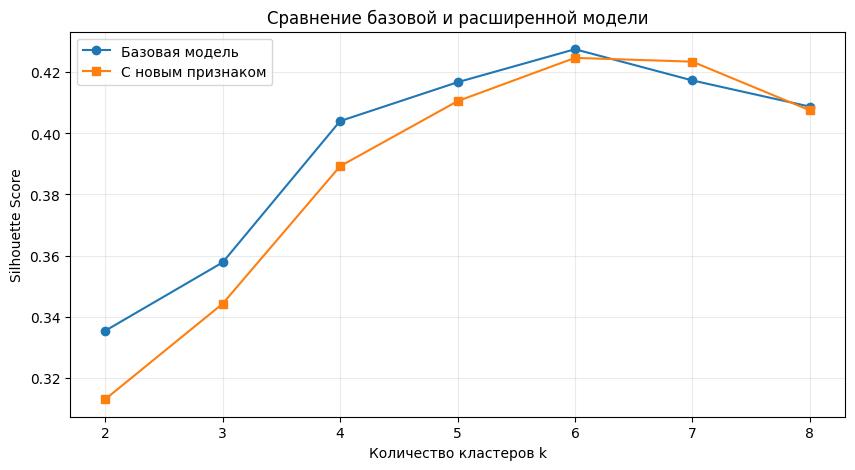

In [15]:
# 5. Сравнение силуэтных оценок базовой и расширенной моделей

comparison_silhouette = pd.merge(
    silhouette_df[["k", "Silhouette Score"]].rename(
        columns={"Silhouette Score": "Базовая модель"}
    ),
    engineered_silhouette_df.rename(
        columns={"Silhouette Score": "С новым признаком"}
    ),
    on="k",
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    comparison_silhouette["k"],
    comparison_silhouette["Базовая модель"],
    marker="o",
    label="Базовая модель",
)

ax.plot(
    comparison_silhouette["k"],
    comparison_silhouette["С новым признаком"],
    marker="s",
    label="С новым признаком",
)

ax.set_xlabel("Количество кластеров k")
ax.set_ylabel("Silhouette Score")
ax.set_title("Сравнение базовой и расширенной модели")
ax.set_xticks(list(SILHOUETTE_K))
ax.grid(alpha=0.25)
ax.legend()

plt.show()


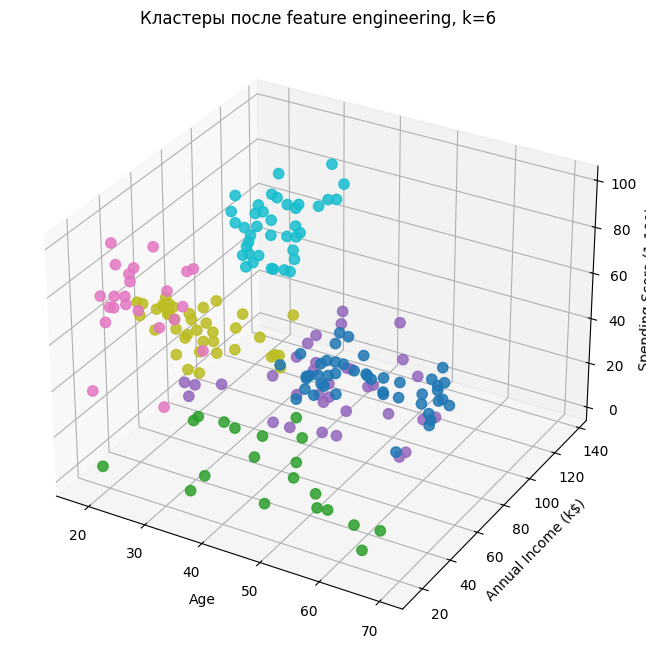

Профиль кластеров расширенной модели:


,Age,Annual Income (k$),Spending Score (1-100),Spending_to_Income
Cluster,,,,
0,56.333,54.267,49.067,0.930
1,46.250,26.750,18.350,0.691
2,41.265,88.500,16.765,0.190
3,25.304,24.304,76.522,3.365
4,26.923,56.205,49.538,0.925
5,32.692,86.538,82.128,0.977


In [16]:
# 5. 3D-визуализация кластеризации с новым признаком

df_engineered["Cluster"] = engineered_labels

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df_engineered["Age"],
    df_engineered["Annual Income (k$)"],
    df_engineered["Spending Score (1-100)"],
    c=df_engineered["Cluster"],
    cmap="tab10",
    s=55,
    alpha=0.85,
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.set_title(
    f"Кластеры после feature engineering, k={engineered_best_k}"
)

plt.show()

print("Профиль кластеров расширенной модели:")
engineered_profile = (
    df_engineered.groupby("Cluster")[FEATURES_ENGINEERED]
    .mean()
    .round(3)
)
display(engineered_profile)


In [17]:
# Итоговые выводы

stability_ari = (
    ari_df.set_index("Инициализация")["Средний ARI"].to_dict()
)

kmeanspp_ari = stability_ari["k-means++"]
random_ari = stability_ari["random"]

score_before = silhouette_score(X_before_scaled, labels_before)
score_after = silhouette_score(X_after_scaled, labels_after)

print("1. Сегментация")
print(
    f"Для базовой модели использовано {BASE_K} кластеров. "
    f"Silhouette Score = {baseline_silhouette:.4f}."
)

print("\n2. K-Means++ и стандартный K-Means")
print(
    f"Средний ARI между запусками K-Means++ = {kmeanspp_ari:.4f}; "
    f"для случайной инициализации = {random_ari:.4f}."
)
if kmeanspp_ari > random_ari:
    print(
        "В этом эксперименте K-Means++ дал более устойчивые разбиения "
        "при изменении random_state."
    )
else:
    print(
        "В этом эксперименте случайная инициализация не уступила "
        "K-Means++ по среднему ARI."
    )

print("\n3. Выбросы")
print(
    f"При |Z| > 3 найдено {int(mask_3.sum())} объектов. "
    f"При |Z| > 2.5 — {int(mask_25.sum())}."
)
print(
    f"Silhouette Score до удаления = {score_before:.4f}, "
    f"после удаления = {score_after:.4f}."
)

print("\n4. Метод силуэта")
print(
    f"Максимальный Silhouette Score для базовых признаков "
    f"получен при k={best_k}: {best_silhouette:.4f}."
)

print("\n5. Новый признак")
print(
    f"После добавления {DERIVED_FEATURE} оптимальное k={engineered_best_k}, "
    f"Silhouette Score={engineered_score:.4f}."
)

score_delta = engineered_score - best_silhouette

if score_delta > 0:
    print(
        f"Добавление признака повысило Silhouette Score на {score_delta:.4f}."
    )
elif score_delta < 0:
    print(
        f"Добавление признака снизило Silhouette Score на "
        f"{abs(score_delta):.4f}; в данном наборе данных "
        "он не улучшил внутреннее качество кластеризации."
    )
else:
    print("Добавление признака не изменило Silhouette Score.")


1. Сегментация
Для базовой модели использовано 6 кластеров. Silhouette Score = 0.4274.

2. K-Means++ и стандартный K-Means
Средний ARI между запусками K-Means++ = 0.7872; для случайной инициализации = 0.7071.
В этом эксперименте K-Means++ дал более устойчивые разбиения при изменении random_state.

3. Выбросы
При |Z| > 3 найдено 0 объектов. При |Z| > 2.5 — 2.
Silhouette Score до удаления = 0.4274, после удаления = 0.4338.

4. Метод силуэта
Максимальный Silhouette Score для базовых признаков получен при k=6: 0.4274.

5. Новый признак
После добавления Spending_to_Income оптимальное k=6, Silhouette Score=0.4246.
Добавление признака снизило Silhouette Score на 0.0028; в данном наборе данных он не улучшил внутреннее качество кластеризации.
